## Definición del problema

Presentar:
  - Contexto del problema. 
  - Objetivo del proyecto. 
  - Pregunta de negocio o investigación. 
  - Justificación de la elección del dataset. 

## Obtención y comprensión de los datos

Podrás utilizar datasets provenientes de:
  - Kaggle 
  - UCI Machine Learning Repository 
  - Datos Abiertos Colombia 
  - APIs públicas 
  - Datos propios (anonimizados) 

Debe incluir:
  - Descripción de las variables. 
  - Dimensiones del dataset. 
  - Tipos de datos. 
  - Diccionario de datos (si está disponible). 

## Análisis Exploratorio de Datos (EDA)

Realizar:
  - Estadísticas descriptivas. 
  - Identificación de valores nulos. 
  - Detección de valores atípicos. 
  - Visualizaciones relevantes. 
  - Hallazgos principales. 

## Preparación de datos

Según corresponda:
  - Limpieza de datos. 
  - Tratamiento de valores faltantes. 
  - Codificación de variables categóricas. 
  - Escalamiento o normalización. 
  - Ingeniería de características. 
  - División entrenamiento/prueba. 

## Modelado

Elige una de las siguientes rutas:

### Ruta A – Aprendizaje Supervisado

Debe incluir:
  - Al menos 2 modelos diferentes. 
  - Comparación de resultados. 
  - Métricas adecuadas. 

### Ruta B – Aprendizaje No Supervisado

Debe incluir:
  - Al menos 2 técnicas. 
  - Interpretación de los grupos encontrados. 

### Ruta C – NLP

Debe incluir:
  - Preprocesamiento de texto. 
  - Vectorización. 
  - Entrenamiento y evaluación. 

### Ruta D – Deep Learning

Debe incluir:
  - Diseño de la arquitectura. 
  - Entrenamiento. 
  - Evaluación. 

## Evaluación

Explicar:
  - Métricas utilizadas. 
  - Interpretación de resultados. 
  - Limitaciones del modelo. 
  - Posibles mejoras. 

## Conclusiones

Responder:
  - ¿Se cumplió el objetivo? 
  - ¿Qué hallazgos relevantes se encontraron? 
  - ¿Qué valor aportaría este proyecto a una organización?

---
## Definición del problema
### Contexto del problema
La calidad del aire constituye un factor rleevante para la salud pública y la gestión ambiental. Con el fenómeno del niño es justificable buscar causas del porqué éste aspecto puede influir en esto. Entre los distintos contaminantes que se pueden monitorear, se encuentra el PM10, compuesto por partículas inhalables cuyo comportamiento puede variar en función de factores temporales y geográficos. 

Para este proyecto se utilizará un conjunto de datos de [calidad del aire de Colombia](https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Calidad-del-Aire-en-Colombia/g4t8-zkc3/about_data), concentrando el análisis en las mediciones de PM10 realizadas en el municipio de Ibagué (mi ciudad), Tolima. Esta delimitación permite estudiar de manera específica el comportamiento temporal de este contaminante y desarrollar un modelo predictivo sobre una zona geográfica concreta.

### Objetivo del proyecto
Desarrollar y evaluar modelos de aprendizaje supervisado capaces de predecir la concentración de PM10 en Ibagué, utilizando información histórica de las mediciones de calidad del aire y variables temporales y características de las estaciones de monitoreo.

### Pregunta de investigación
¿Es posible predecir la concentración de PM10 en Ibagué utilizando los valores históricos de concentración, variables temporales y características de las estaciones de monitoreo?

### Justificación de la elección del dataset
El conjunto de datos fue seleccionado debido a que contiene mediciones reales de calidad del aire recopiladas mediante estaciones de monitoreo ubicadas en Colombia. Entre sus variables se encuentran la concentración del contaminante, fecha y hora de medición, ubicación geográfica, altitud, duración del monitoreo y características de la estación (donde se mide). Centrarme en Ibagué, me permite reducir la variabilidad asociada a comparar diferentes ciudades o condiciones ambientales, centralizando el alcance para evaluar los modelos.

## Obtención y comprensión de los datos
### Descripción del dataset
 - Fuente: https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Calidad-del-Aire-en-Colombia/g4t8-zkc3/about_data
 - Nombre: Calidad del Aire en Colombia
 - Última actualización de los datos: 20 de febrero de 2026
 - Filas (sin procesar): 32.8M
 - Columnas (sin procesar): 18
### Variables
| Variable                     | Descripción                                 | Tipo       |
| ---------------------------- | ------------------------------------------- | ---------- |
| `ESTACION_ID`                | Identificador de la estación                | Categórica |
| `NOMBRE_FGDA`                | Autoridad ambiental responsable             | Categórica |
| `NOMBRE_EST`                 | Nombre de la estación                       | Categórica |
| `MSFL_CODE`                  | Contaminante atmosférico medido             | Categórica |
| `MED_CONCENTRACION_ESTANDAR` | Concentración medida del contaminante       | Numérica   |
| `MED_FECHA_INICIO`           | Fecha y hora de inicio de la medición       | Temporal   |
| `MED_FECHA_FINAL`            | Fecha y hora final de la medición           | Temporal   |
| `LATITUD`                    | Latitud de la estación                      | Numérica   |
| `LONGITUD`                   | Longitud de la estación                     | Numérica   |
| `ALTITUD`                    | Altitud sobre el nivel del mar              | Numérica   |
| `NOMBRE_UNIDAD`              | Unidad de medida                            | Categórica |
| `SIGLA_UNIDAD`               | Sigla de la unidad de medida                | Categórica |
| `DURACIÓN`                   | Duración del monitoreo en minutos           | Numérica   |
| `CODIGO_DEPARTAMENTO`        | Código DANE del departamento                | Categórica |
| `DEPARTAMENTO`               | Departamento donde se encuentra la estación | Categórica |
| `CODIGO_MUNICIPIO`           | Código DANE del municipio                   | Categórica |
| `MUNICIPIO`                  | Municipio donde se encuentra la estación    | Categórica |
| `TIPO_ESTACION`              | Tipo de estación de monitoreo               | Categórica |

### Carga de datos

In [100]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [101]:
df = pd.read_csv('dataset.csv') # El dataset ya lo descargué filtrado para IBAGUÉ
df.head()

,ESTACION_ID,NOMBRE_FGDA,NOMBRE_EST,MSFL_CODE,MED_CONCENTRACION_ESTANDAR,MED_FECHA_INICIO,MED_FECHA_FINAL,LATITUD,LONGITUD,ALTITUD,NOMBRE_UNIDAD,SIGLA_UNIDAD,DURACIÓN,CODIGO_DEPARTAMENTO,DEPARTAMENTO,CODIGO_MUNICIPIO,MUNICIPIO,TIPO_ESTACION
0,8258,CORTOLIMA,CORTOLIMA,PM10,35.55,2020 Feb 26 12:00:00 AM,2020 Feb 27 12:00:00 AM,4.433181,-75.211139,"1,191",Microgramos por metro cúbico,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija
1,8258,CORTOLIMA,CORTOLIMA,PM10,26.95,2020 Jun 25 12:00:00 AM,2020 Jun 26 12:00:00 AM,4.433181,-75.211139,"1,191",Microgramos por metro cúbico,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija
2,8258,CORTOLIMA,CORTOLIMA,PM10,17.72,2020 Apr 27 12:00:00 AM,2020 Apr 28 12:00:00 AM,4.433181,-75.211139,"1,191",Microgramos por metro cúbico,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija
3,8258,CORTOLIMA,CORTOLIMA,PM10,41.74,2020 Sep 23 12:00:00 AM,2020 Sep 24 12:00:00 AM,4.433181,-75.211139,"1,191",Microgramos por metro cúbico,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija
4,8258,CORTOLIMA,CORTOLIMA,PM10,33.49,2020 Aug 25 12:00:00 AM,2020 Aug 26 12:00:00 AM,4.433181,-75.211139,"1,191",Microgramos por metro cúbico,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija


In [102]:
df.tail()

,ESTACION_ID,NOMBRE_FGDA,NOMBRE_EST,MSFL_CODE,MED_CONCENTRACION_ESTANDAR,MED_FECHA_INICIO,MED_FECHA_FINAL,LATITUD,LONGITUD,ALTITUD,NOMBRE_UNIDAD,SIGLA_UNIDAD,DURACIÓN,CODIGO_DEPARTAMENTO,DEPARTAMENTO,CODIGO_MUNICIPIO,MUNICIPIO,TIPO_ESTACION
2139,8258,CORTOLIMA,CORTOLIMA,PM10,31.42,2024 Dec 24 12:00:00 AM,2024 Dec 25 12:00:00 AM,4.433181,-75.211139,"1,191",Microgramos por metro cúbico,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija
2140,8258,CORTOLIMA,CORTOLIMA,PM10,29.42,2024 Jan 10 12:00:00 AM,2024 Jan 11 12:00:00 AM,4.433181,-75.211139,"1,191",Microgramos por metro cúbico,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija
2141,8258,CORTOLIMA,CORTOLIMA,PM10,29.99,2024 Apr 20 12:00:00 AM,2024 Apr 21 12:00:00 AM,4.433181,-75.211139,"1,191",Microgramos por metro cúbico,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija
2142,8258,CORTOLIMA,CORTOLIMA,PM10,35.29,2024 Oct 01 12:00:00 AM,2024 Oct 02 12:00:00 AM,4.433181,-75.211139,"1,191",Microgramos por metro cúbico,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija
2143,8258,CORTOLIMA,CORTOLIMA,PM10,37.72,2024 Feb 26 12:00:00 AM,2024 Feb 27 12:00:00 AM,4.433181,-75.211139,"1,191",Microgramos por metro cúbico,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija


In [103]:
rows, columns = df.shape
print(f"Columns: {columns}")
print(f"Rows: {rows}")

Columns: 18
Rows: 2144


### Dimensiones del dataset
Tamaño original: 32.8M Filas
Tamaño filtrado (archivo dataset.csv): 2144 Filas
Columnas: 18

### Tipos de datos

In [104]:
df.dtypes

ESTACION_ID                     int64
NOMBRE_FGDA                       str
NOMBRE_EST                        str
MSFL_CODE                         str
MED_CONCENTRACION_ESTANDAR    float64
MED_FECHA_INICIO                  str
MED_FECHA_FINAL                   str
LATITUD                       float64
LONGITUD                      float64
ALTITUD                           str
NOMBRE_UNIDAD                     str
SIGLA_UNIDAD                      str
DURACIÓN                          str
CODIGO_DEPARTAMENTO             int64
DEPARTAMENTO                      str
CODIGO_MUNICIPIO                int64
MUNICIPIO                         str
TIPO_ESTACION                     str
dtype: object

In [105]:
df["MED_FECHA_INICIO"] = pd.to_datetime(
    df["MED_FECHA_INICIO"],
    errors="coerce"
)

df["MED_FECHA_FINAL"] = pd.to_datetime(
    df["MED_FECHA_FINAL"],
    errors="coerce"
)

df = df.dropna(
    subset=["MED_CONCENTRACION_ESTANDAR"]
)

/tmp/ipykernel_945943/1866807158.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["MED_FECHA_INICIO"] = pd.to_datetime(
/tmp/ipykernel_945943/1866807158.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["MED_FECHA_FINAL"] = pd.to_datetime(


In [106]:
print("Start date:", df["MED_FECHA_INICIO"].min())
print("End date:", df["MED_FECHA_FINAL"].max())

Start date: 2020-01-01 00:00:00
End date: 2024-12-31 00:00:00


In [107]:
print("MSFL_CODE:", df["MSFL_CODE"].unique())

MSFL_CODE: <StringArray>
['PM10']
Length: 1, dtype: str


In [108]:
# Nulos
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts)

duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

negativos = (
    df["MED_CONCENTRACION_ESTANDAR"] < 0
).sum()

print(f"Valores negativos: {negativos}")

Null values per column:
ESTACION_ID                   0
NOMBRE_FGDA                   0
NOMBRE_EST                    0
MSFL_CODE                     0
MED_CONCENTRACION_ESTANDAR    0
MED_FECHA_INICIO              0
MED_FECHA_FINAL               0
LATITUD                       0
LONGITUD                      0
ALTITUD                       0
NOMBRE_UNIDAD                 0
SIGLA_UNIDAD                  0
DURACIÓN                      0
CODIGO_DEPARTAMENTO           0
DEPARTAMENTO                  0
CODIGO_MUNICIPIO              0
MUNICIPIO                     0
TIPO_ESTACION                 0
dtype: int64
Number of duplicate rows: 0
Valores negativos: 0


In [109]:
# Estadísticas descriptivas de PM10
agg_stats = df['MED_CONCENTRACION_ESTANDAR'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
)

print(agg_stats)

count     2144.000000
mean        28.093153
median      27.345000
std          5.373927
min          0.000000
max         53.360000
Name: MED_CONCENTRACION_ESTANDAR, dtype: float64


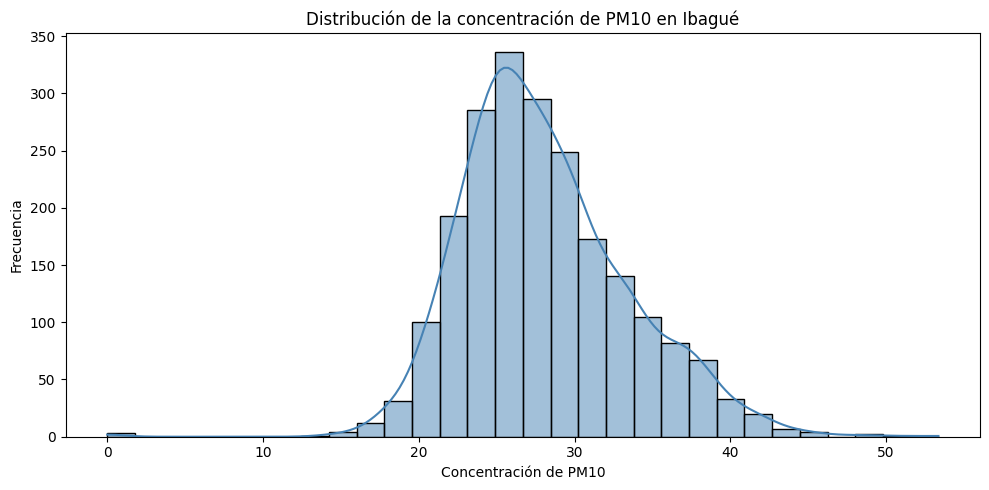

In [110]:
# Distribution plot for PM10 concentration
plt.figure(figsize=(10, 5))
sns.histplot(df['MED_CONCENTRACION_ESTANDAR'], bins=30, kde=True, color='steelblue')
plt.title('Distribución de la concentración de PM10 en Ibagué')
plt.xlabel('Concentración de PM10')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

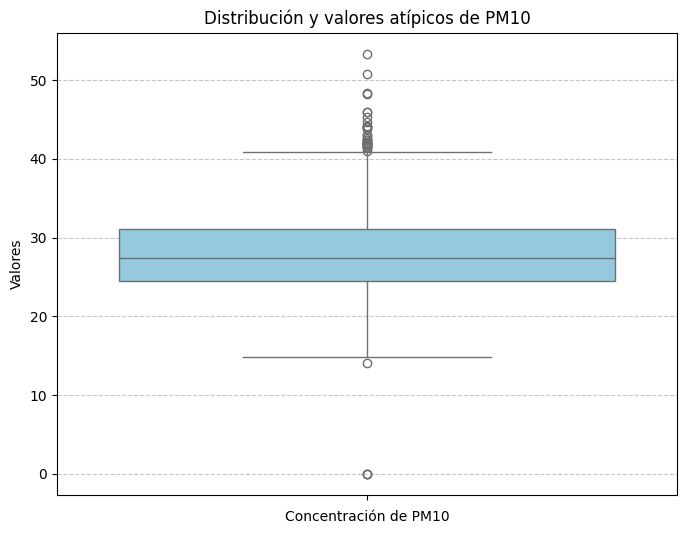

In [111]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='MED_CONCENTRACION_ESTANDAR', data=df, color='skyblue')
plt.title('Distribución y valores atípicos de PM10')
plt.xlabel('Concentración de PM10')
plt.ylabel('Valores')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

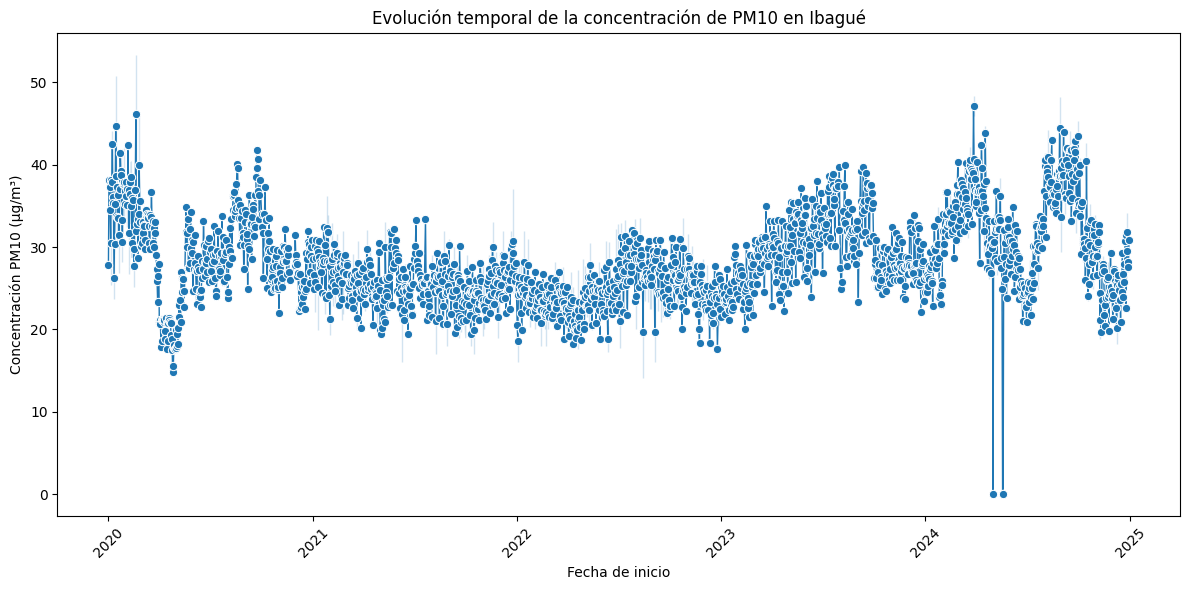

In [112]:
df.sort_values('MED_FECHA_INICIO', inplace=True)

# Gráfico de línea
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x='MED_FECHA_INICIO',
    y='MED_CONCENTRACION_ESTANDAR',
    marker='o',
    linewidth=1
)
plt.title('Evolución temporal de la concentración de PM10 en Ibagué')
plt.xlabel('Fecha de inicio')
plt.ylabel('Concentración PM10 (µg/m³)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hallazgos principales

El conjunto analizado contiene 2.144 mediciones de PM10 correspondientes al período comprendido entre enero de 2020 y diciembre de 2024. La concentración promedio fue de 28,09 µg/m³, con una mediana de 27,35 µg/m³ y una desviación estándar de 5,37 µg/m³. Los valores registrados se encuentran entre 0 y 53,36 µg/m³.

La distribución de las concentraciones se encuentra principalmente entre 20 y 35 µg/m³, con una mayor concentración de observaciones alrededor de 25–30 µg/m³ y una cola hacia valores superiores. El análisis mediante boxplot permitió identificar varios valores potencialmente atípicos, principalmente por encima de 40 µg/m³.

También se identificaron registros con concentración de 0 µg/m³, los cuales requieren una revisión adicional para determinar si corresponden a mediciones válidas o a posibles inconsistencias del sistema de monitoreo. Debido a que los valores extremos pueden representar episodios reales de contaminación, estos no serán eliminados automáticamente.

Finalmente, el análisis temporal evidencia variaciones importantes en la concentración de PM10 a lo largo del período 2020–2024, con períodos de mayor estabilidad y otros de mayor variabilidad. Este comportamiento respalda la utilización de variables temporales y valores históricos de PM10 como posibles predictores en los modelos de aprendizaje supervisado.

---
## Preparación de los datos

In [113]:
# Limpieza inicial
df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.strip()
    .str.upper()
)
df_model = df_model.sort_values(
    ["ESTACION_ID", "MED_FECHA_INICIO"]
).reset_index(drop=True)

# Por procesamientos posteriores me di cuenta de que lo mejor era deshacerse de la estación 31477 ya que son pocos valores y para entrenar el modelo iba a ser
# problemático

df_model = df_model[
    df_model["ESTACION_ID"] == 8258
].copy()


In [114]:
# Extracción de valores temporales útiles para el modelado

df_model["dia"] = (
    df_model["MED_FECHA_INICIO"].dt.day
)

df_model["mes"] = (
    df_model["MED_FECHA_INICIO"].dt.month
)

df_model["año"] = (
    df_model["MED_FECHA_INICIO"].dt.year
)



In [115]:
df_model.head(5)

,ESTACION_ID,NOMBRE_FGDA,NOMBRE_EST,MSFL_CODE,MED_CONCENTRACION_ESTANDAR,MED_FECHA_INICIO,MED_FECHA_FINAL,LATITUD,LONGITUD,ALTITUD,...,SIGLA_UNIDAD,DURACIÓN,CODIGO_DEPARTAMENTO,DEPARTAMENTO,CODIGO_MUNICIPIO,MUNICIPIO,TIPO_ESTACION,dia,mes,año
0,8258,CORTOLIMA,CORTOLIMA,PM10,27.84,2020-01-01,2020-01-02,4.433181,-75.211139,"1,191",...,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija,1,1,2020
1,8258,CORTOLIMA,CORTOLIMA,PM10,37.33,2020-01-03,2020-01-04,4.433181,-75.211139,"1,191",...,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija,3,1,2020
2,8258,CORTOLIMA,CORTOLIMA,PM10,34.45,2020-01-04,2020-01-05,4.433181,-75.211139,"1,191",...,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija,4,1,2020
3,8258,CORTOLIMA,CORTOLIMA,PM10,35.74,2020-01-05,2020-01-06,4.433181,-75.211139,"1,191",...,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija,5,1,2020
4,8258,CORTOLIMA,CORTOLIMA,PM10,38.10,2020-01-06,2020-01-07,4.433181,-75.211139,"1,191",...,ug/m3,"1,440",73,Tolima,73001,Ibagué,Fija,6,1,2020


In [116]:
# Procesar días repetidos e identificar días faltantes (secuencia)

dupes = df_model.duplicated(subset=["ESTACION_ID", "MED_FECHA_INICIO"]).sum()
print(f"Número de filas duplicadas: {dupes}")

missing_dates = pd.date_range(
    start=df_model["MED_FECHA_INICIO"].min(),
    end=df_model["MED_FECHA_INICIO"].max(),
    freq="D"
)
print(f"Número de días faltantes: {len(missing_dates) - df_model['MED_FECHA_INICIO'].nunique()}")

Número de filas duplicadas: 0
Número de días faltantes: 55


In [117]:
# Automatizar creación de lags

def add_date_lag(df, days, target="MED_CONCENTRACION_ESTANDAR"):
    history = df[
        [
            "ESTACION_ID",
            "MED_FECHA_INICIO",
            target
        ]
    ].copy()

    history["MED_FECHA_INICIO"] = (
        history["MED_FECHA_INICIO"]
        + pd.Timedelta(days=days)
    )

    history = history.rename(
        columns={
            target: f"pm10_lag_{days}"
        }
    )

    return df.merge(
        history,
        on=["ESTACION_ID", "MED_FECHA_INICIO"],
        how="left"
    )


In [118]:
# Creación de lags de 1, 7, 30, 365 días
lag_days = [1, 7, 30, 365]
for days in lag_days:
    df_model = add_date_lag(df_model, days)

In [119]:
features = [
    "pm10_lag_1",
    "pm10_lag_7",
    "pm10_lag_30",
    "pm10_lag_365"
]

for feature in features:
    print(
        feature,
        df_model[feature].notna().sum()
    )

pm10_lag_1 1730
pm10_lag_7 1713
pm10_lag_30 1690
pm10_lag_365 1376


In [120]:
for feature in features:
    print(
        f"{feature}:",
        round(df_model[feature].notna().mean() * 100, 2),
        "%"
    )

pm10_lag_1: 97.68 %
pm10_lag_7: 96.73 %
pm10_lag_30: 95.43 %
pm10_lag_365: 77.7 %


In [121]:
df_model.groupby("ESTACION_ID")[features].apply(
    lambda x: x.notna().mean() * 100
)

,pm10_lag_1,pm10_lag_7,pm10_lag_30,pm10_lag_365
ESTACION_ID,,,,
8258,97.684924,96.725014,95.426313,77.696217


In [122]:
df_model.head(5)

,ESTACION_ID,NOMBRE_FGDA,NOMBRE_EST,MSFL_CODE,MED_CONCENTRACION_ESTANDAR,MED_FECHA_INICIO,MED_FECHA_FINAL,LATITUD,LONGITUD,ALTITUD,...,CODIGO_MUNICIPIO,MUNICIPIO,TIPO_ESTACION,dia,mes,año,pm10_lag_1,pm10_lag_7,pm10_lag_30,pm10_lag_365
0,8258,CORTOLIMA,CORTOLIMA,PM10,27.84,2020-01-01,2020-01-02,4.433181,-75.211139,"1,191",...,73001,Ibagué,Fija,1,1,2020,NaN,NaN,NaN,NaN
1,8258,CORTOLIMA,CORTOLIMA,PM10,37.33,2020-01-03,2020-01-04,4.433181,-75.211139,"1,191",...,73001,Ibagué,Fija,3,1,2020,NaN,NaN,NaN,NaN
2,8258,CORTOLIMA,CORTOLIMA,PM10,34.45,2020-01-04,2020-01-05,4.433181,-75.211139,"1,191",...,73001,Ibagué,Fija,4,1,2020,37.33,NaN,NaN,NaN
3,8258,CORTOLIMA,CORTOLIMA,PM10,35.74,2020-01-05,2020-01-06,4.433181,-75.211139,"1,191",...,73001,Ibagué,Fija,5,1,2020,34.45,NaN,NaN,NaN
4,8258,CORTOLIMA,CORTOLIMA,PM10,38.10,2020-01-06,2020-01-07,4.433181,-75.211139,"1,191",...,73001,Ibagué,Fija,6,1,2020,35.74,NaN,NaN,NaN


In [123]:
df_model.tail(5)

,ESTACION_ID,NOMBRE_FGDA,NOMBRE_EST,MSFL_CODE,MED_CONCENTRACION_ESTANDAR,MED_FECHA_INICIO,MED_FECHA_FINAL,LATITUD,LONGITUD,ALTITUD,...,CODIGO_MUNICIPIO,MUNICIPIO,TIPO_ESTACION,dia,mes,año,pm10_lag_1,pm10_lag_7,pm10_lag_30,pm10_lag_365
1766,8258,CORTOLIMA,CORTOLIMA,PM10,29.50,2024-12-26,2024-12-27,4.433181,-75.211139,"1,191",...,73001,Ibagué,Fija,26,12,2024,22.58,26.75,25.21,30.34
1767,8258,CORTOLIMA,CORTOLIMA,PM10,29.58,2024-12-27,2024-12-28,4.433181,-75.211139,"1,191",...,73001,Ibagué,Fija,27,12,2024,29.50,22.33,29.29,28.28
1768,8258,CORTOLIMA,CORTOLIMA,PM10,28.21,2024-12-28,2024-12-29,4.433181,-75.211139,"1,191",...,73001,Ibagué,Fija,28,12,2024,29.58,28.00,25.13,26.18
1769,8258,CORTOLIMA,CORTOLIMA,PM10,26.92,2024-12-29,2024-12-30,4.433181,-75.211139,"1,191",...,73001,Ibagué,Fija,29,12,2024,28.21,25.71,22.42,23.39
1770,8258,CORTOLIMA,CORTOLIMA,PM10,30.83,2024-12-30,2024-12-31,4.433181,-75.211139,"1,191",...,73001,Ibagué,Fija,30,12,2024,26.92,30.08,24.63,NaN


In [124]:
target = df_model[
    [
        "ESTACION_ID",
        "MED_FECHA_INICIO",
        "MED_CONCENTRACION_ESTANDAR"
    ]
].copy()

target["MED_FECHA_INICIO"] = (
    target["MED_FECHA_INICIO"] -
    pd.Timedelta(days=1)
)

target = target.rename(
    columns={
        "MED_CONCENTRACION_ESTANDAR": "target_pm10"
    }
)

df_model = df_model.merge(
    target[
        [
            "ESTACION_ID",
            "MED_FECHA_INICIO",
            "target_pm10"
        ]
    ],
    on=[
        "ESTACION_ID",
        "MED_FECHA_INICIO"
    ],
    how="left"
)

In [125]:
df_model[
    [
        "MED_FECHA_INICIO",
        "MED_CONCENTRACION_ESTANDAR",
        "pm10_lag_1",
        "pm10_lag_7",
        "pm10_lag_30",
        "pm10_lag_365",
        "target_pm10"
    ]
].tail(10)

,MED_FECHA_INICIO,MED_CONCENTRACION_ESTANDAR,pm10_lag_1,pm10_lag_7,pm10_lag_30,pm10_lag_365,target_pm10
1761,2024-12-21,28.00,22.33,23.42,26.08,29.74,25.71
1762,2024-12-22,25.71,28.00,20.92,23.96,25.80,30.08
1763,2024-12-23,30.08,25.71,25.54,24.54,22.08,31.42
1764,2024-12-24,31.42,30.08,25.67,19.75,27.88,22.58
1765,2024-12-25,22.58,31.42,29.33,24.33,28.02,29.50
1766,2024-12-26,29.50,22.58,26.75,25.21,30.34,29.58
1767,2024-12-27,29.58,29.50,22.33,29.29,28.28,28.21
1768,2024-12-28,28.21,29.58,28.00,25.13,26.18,26.92
1769,2024-12-29,26.92,28.21,25.71,22.42,23.39,30.83
1770,2024-12-30,30.83,26.92,30.08,24.63,NaN,NaN


In [126]:
df_model = df_model.dropna(
    subset=["target_pm10"]
).copy()

In [127]:
# Verificar antes de entrenar

features = [
    "MED_CONCENTRACION_ESTANDAR",
    "pm10_lag_1",
    "pm10_lag_7",
    "pm10_lag_30",
    "pm10_lag_365"
]

target = "target_pm10"

df_model = df_model.dropna(
    subset=features + [target]
).copy()

print("Registros finales:", len(df_model))

Registros finales: 1250


Tendrá que servir, ahora a entrenar

## Modelado
### Aprendizaje supervisado
Modelos seleccionados:

- Regresión Lineal: Justificación > Fácil de interpretar, es básico y nos permite saber cuánto mejora un modelo no lineal
- Random Forest: Justificación > Captura relaciones no lineales entre los históricos, es una buena segunda opción para este dataset y no requiere escalamiento
  

* las variables ya las había definido jeje

In [128]:
# Como estamos tratando de predecir el futuro muajaja, toca hacer una división temporal

split_index = int(len(df_model) * 0.8)

train = df_model.iloc[:split_index]
test = df_model.iloc[split_index:]

print("Train:", train.shape)
print("Test:", test.shape)

print(
    "Train:",
    train["MED_FECHA_INICIO"].min(),
    "→",
    train["MED_FECHA_INICIO"].max()
)

print(
    "Test:",
    test["MED_FECHA_INICIO"].min(),
    "→",
    test["MED_FECHA_INICIO"].max()
)

Train: (1000, 26)
Test: (250, 26)
Train: 2021-01-02 00:00:00 → 2024-04-12 00:00:00
Test: 2024-04-13 00:00:00 → 2024-12-29 00:00:00


In [129]:
# Crear X e Y
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [130]:
# Escalado para Regresión lineal
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [131]:
# Regresión lineal

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

y_pred_linear = linear_model.predict(
    X_test_scaled
)

In [132]:
# Random Forest

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

## Evaluación

In [133]:
# Evaluación de modelos

results = []

for name, y_pred in [
    ("Regresión Lineal", y_pred_linear),
    ("Random Forest", y_pred_rf)
]:
    
    mae = mean_absolute_error(
        y_test,
        y_pred
    )
    
    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5
    
    r2 = r2_score(
        y_test,
        y_pred
    )
    
    results.append({
        "Modelo": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

results_df

,Modelo,MAE,RMSE,R²
0,Regresión Lineal,2.948823,4.481279,0.532569
1,Random Forest,2.761200,4.242033,0.581147


### Interpretación de resultados

**Regresión Lineal:**
- **MAE (2.95 µg/m³):** En promedio, las predicciones del modelo se desvían casi 3 µg/m³ del valor real observado.
- **RMSE (4.48 µg/m³):** Al ser mayor que el MAE, refleja que los picos o variaciones bruscas de PM10 penalizan más al modelo.
- **R² (0.533):** Logra explicar un 53.3% de la variabilidad del PM10 a partir de las variables históricas.

**Random Forest (Modelo con mejor desempeño):**
- **MAE (2.76 µg/m³):** Reduce el error promedio en aprox. un 6% frente a la Regresión Lineal.
- **RMSE (4.24 µg/m³):** Disminuye aprox. un 5%, mostrando un mejor manejo de los valores extremos.
- **R² (0.581):** Aumenta la capacidad explicativa al 58.1% (aprox. un 9% superior).

A pesar de que la diferencia numérica no es abismal, Random Forest demostró un mejor desempeño general. Esto indica que las concentraciones históricas de PM10 guardan relaciones no lineales con la concentración del día siguiente, aunque una parte importante del comportamiento se deja capturar razonablemente bien por un modelo lineal.

### Limitaciones del modelo y posibles mejoras
- **Pérdida de datos por lags:** Al calcular el lag de 365 días para capturar patrones anuales, el volumen de datos utilizable se redujo de 2.144 a 1.250 filas.
- **Falta de variables exógenas:** El modelo depende únicamente del historial de PM10. Integrar datos meteorológicos (lluvia, viento, humedad o temperatura) ayudaría a predecir mejor los cambios repentinos.
- **Discontinuidad temporal:** La presencia de días faltantes en los registros originales dificulta la creación de secuencias temporales totalmente continuas.


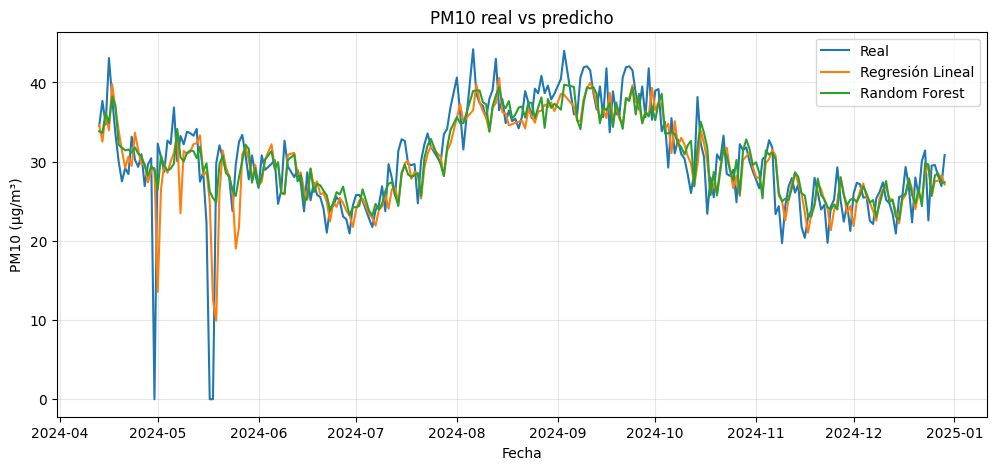

In [134]:
plt.figure(figsize=(12, 5))

plt.plot(
    test["MED_FECHA_INICIO"],
    y_test,
    label="Real"
)

plt.plot(
    test["MED_FECHA_INICIO"],
    y_pred_linear,
    label="Regresión Lineal"
)

plt.plot(
    test["MED_FECHA_INICIO"],
    y_pred_rf,
    label="Random Forest"
)

plt.title("PM10 real vs predicho")
plt.xlabel("Fecha")
plt.ylabel("PM10 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

La gráfica anterior ilustra muy bien este comportamiento: ambos modelos siguen la tendencia general de la serie temporal en Ibagué, pero Random Forest logra reaccionar mejor ante las variaciones del PM10 sin perder la trayectoria media.

---
## Conclusiones

### ¿Se cumplió el objetivo?
Sí, se desarrolló un modelo de aprendizaje supervisado capaz de predecir la concentración de PM10 en Ibagué utilizando información histórica de las mediciones de calidad del aire y variables temporales.

### ¿Qué hallazgos relevantes se encontraron?
- El comportamiento reciente e histórico del PM10 tiene capacidad predictiva directa sobre la concentración del día siguiente.
- Aunque Random Forest obtuvo el mejor rendimiento, la diferencia cercana respecto a la Regresión Lineal muestra que una parte importante del fenómeno responde a patrones lineales sencillos.
- Los modelos presentan mayor dificultad para predecir picos repentinos de contaminación al no contar con información ambiental externa (clima, viento).
- La calidad y continuidad de los datos condicionan el modelado: los días faltantes limitan el uso de lags extensos.

### ¿Qué valor aportaría este proyecto a una organización?
Serviría como una herramienta complementaria de apoyo a la gestión ambiental en Ibagué (por ejemplo, para entidades como Cortolima o la Alcaldía).

Permite evaluar si las políticas de conservación están funcionando al comparar lo proyectado con lo observado: *"Hoy proyectamos que la tendencia del próximo período sería esta, pero fue diferente; esto nos ayuda a medir el impacto real de las iniciativas implementadas"*.
Asimismo, facilita la anticipación de eventos estacionales y la creación de planes de contingencia antes de que se presenten emergencias de salud pública.
